## SETUP

In [44]:
!pip install dezerogym

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from dezerogym.gridworld import GridWorld

## ch07/dezero1.py

In [9]:
# Inner products
a = torch.tensor([1, 2, 3])
b = torch.tensor([4, 5, 6])
# a, b = torch.tensor(a), torch.tensor(b)
c =   torch.matmul(a, b)
print(c)

# Matrix product
a = torch.tensor([[1, 2], [3, 4]])
b = torch.tensor([[5, 6], [7, 8]])
c = torch.matmul(a, b)
print(c)

tensor(32)
tensor([[19, 22],
        [43, 50]])


## ch07/dezero2.py

In [ ]:
# 最小値を求める関数の指標となるrosenbrock関数
def rosenbrock(x0, x1):
    y = 100 * (x1 - x0 ** 2) ** 2 + (x0 - 1) ** 2
    return y

x0 = torch.tensor(2., requires_grad=True) # requires_grad=Trueで勾配を計算を指示, 初期値を2に設定
x1 = torch.tensor(2., requires_grad=True) # requires_grad=Trueで勾配を計算を指示, 初期値を2に設定

lr = 0.001
iters = 10000

# 最小値を求める
for i in range(iters):
    y = rosenbrock(x0, x1)

    # 勾配を初期化
    if x0.grad is not None:
        x0.grad.zero_()
    if x1.grad is not None:
        x1.grad.zero_()
    y.backward()

    with torch.no_grad():
        x0 -= lr * x0.grad
        x1 -= lr * x1.grad

print(x0, x1)

tensor(1.0081, requires_grad=True) tensor(1.0162, requires_grad=True)


## ch07/dezero3.py

In [4]:
np.zeros(1)
torch.zeros(1)

tensor([0.])

tensor(41.8980)
tensor(0.2248)
tensor(0.0925)
tensor(0.0888)
tensor(0.0863)
tensor(0.0844)
tensor(0.0829)
tensor(0.0818)
tensor(0.0810)
tensor(0.0803)
====
W = tensor([[2.2864]])
b = tensor([5.3145])


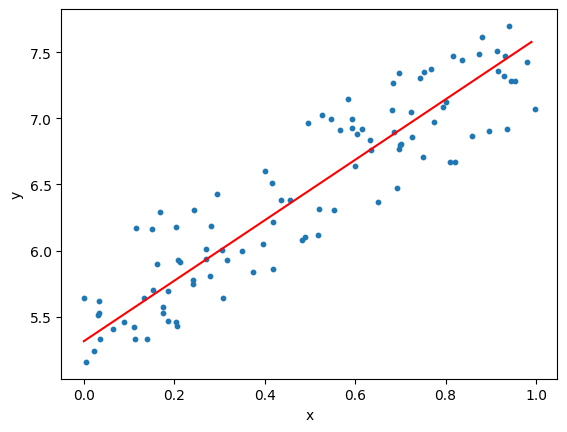

In [ ]:
# トイ・データセット
torch.manual_seed(0)

# x: 0~1の乱数を100個生成し、(100, 1)の形状に変形(reshapeは-1で自動調整)
x = torch.rand(100).reshape(-1, 1)
y = 5 + 2 * x + torch.rand(100).reshape(-1, 1)

# 重みとバイアスの初期化
W = torch.zeros((1, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

# 予測関数
def predict(x):
    y = torch.matmul(x, W) + b
    return y

# 平均二乗誤差
def mean_squared_error(x0, x1):
    diff = x0 - x1
    return torch.sum(diff ** 2) / len(diff)

lr = 0.1
iters = 100

for i in range(iters):
    y_pred = predict(x)
    loss = mean_squared_error(y, y_pred)

    # 勾配を初期化
    if W.grad is not None:
        W.grad.zero_()
    if b.grad is not None:
        b.grad.zero_()
    loss.backward()

    with torch.no_grad():
      W -= lr * W.grad
      b -= lr * b.grad

    if i % 10 == 0:
        print(loss.data)

print('====')
print('W =', W.data)
print('b =', b.data)

# Plot
plt.scatter(x.data, y.data, s=10)
plt.xlabel('x')
plt.ylabel('y')
t = torch.arange(0, 1, .01)[:, np.newaxis]
y_pred = predict(t)
plt.plot(t, y_pred.data, color='r')
plt.show()

## ch07/dezero4.py

tensor(0.8830)
tensor(0.2484)
tensor(0.2435)
tensor(0.2337)
tensor(0.2122)
tensor(0.1489)
tensor(0.0844)
tensor(0.1885)
tensor(0.0769)
tensor(0.0767)


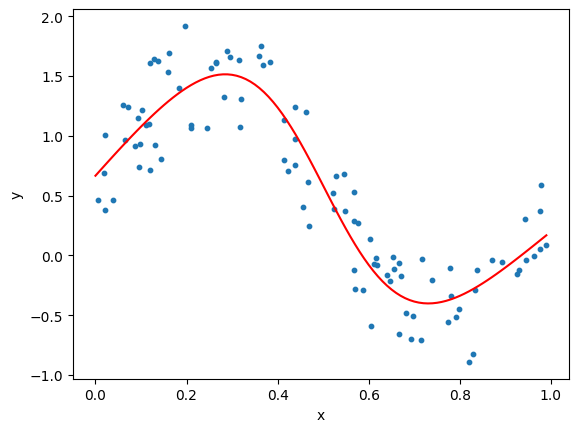

In [6]:
# Dataset
np.random.seed(0)
x = np.random.rand(100, 1)
y = np.sin(2 * np.pi * x) + np.random.rand(100, 1)

# NumPy -> Torch tensor に変換
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)


lr = 0.2
iters = 10000

# nn.Moduleを継承したニューラルネットワークの定義(torchの基本)
class TwoLayerNet(nn.Module):
    def __init__(self, hidden_size, out_size):
        super().__init__()
        self.l1 = nn.Linear(1, hidden_size)
        self.l2 = nn.Linear(hidden_size, out_size)
        self.sigmoid = nn.Sigmoid()

    # 順伝播
    def forward(self, x):
        y = self.sigmoid(self.l1(x))
        y = self.l2(y)
        return y

# 隠れ層のノード数10、出力1のニューラルネットワークを生成
model = TwoLayerNet(10, 1)
# オプティマイザーによる最適化手法の設定(確率的勾配降下法)
sgd = optim.SGD(model.parameters(), lr)
loss_fn = nn.MSELoss()

for i in range(iters):
    y_pred = model(x)
    loss = loss_fn(y, y_pred)

    # 勾配を初期化
    sgd.zero_grad()
    loss.backward()
    sgd.step()

    if i % 1000 == 0:
        print(loss.data)

# Plot
plt.scatter(x, y, s=10)
plt.xlabel('x')
plt.ylabel('y')
t = np.arange(0, 1, .01)[:, np.newaxis]
t_tensor = torch.tensor(t, dtype=torch.float32)
y_pred = model(t_tensor)
plt.plot(t, y_pred.detach().numpy(), color='r')
plt.show()

## ch07/q_learning_nn.py

c:\Users\PC_Uer\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


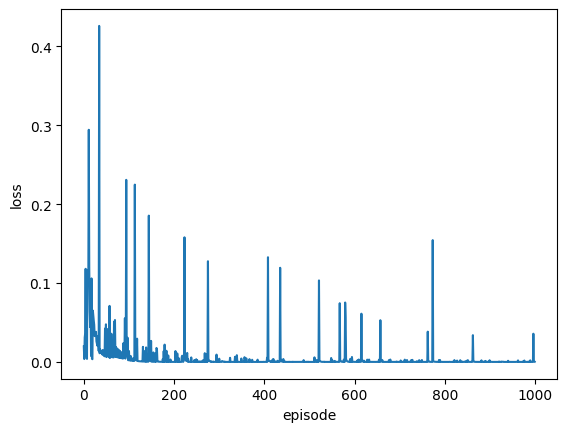

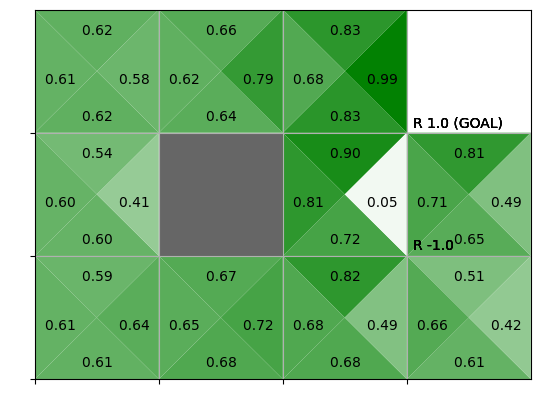

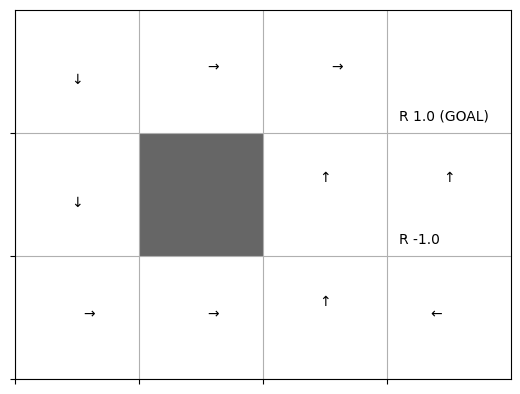

In [3]:
# グリッドワールドの状態をone-hotベクトルに変換
# グリッドワールドは(縦,横)の配列で状態を表現
# これを3x4=12の1次元one-hotベクトルに変換
def one_hot(state):
    HEIGHT, WIDTH = 3, 4
    vec = np.zeros(HEIGHT * WIDTH, dtype=np.float32)
    y, x = state
    idx = WIDTH * y + x
    vec[idx] = 1.0
    return torch.tensor(vec[np.newaxis, :], dtype=torch.float32) # バッチの次元を追加し、(1, 12)の形状に変換

# Q-network
# 入力は12次元(one-hotベクトル)、出力は4次元(各行動のQ値)
# 隠れ層1層、活性化関数ReLU
class QNet(nn.Module):
    def __init__(self, hidden_size=100, action_size=4):
        super().__init__()
        self.l1 = nn.Linear(12, hidden_size)  # 3 * 4 = 12
        self.l2 = nn.Linear(hidden_size, action_size)
        self.relu = nn.ReLU()

    # 順伝播
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.l2(x)
        return x


class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.lr = 0.01
        self.epsilon = 0.1
        self.action_size = 4

        # Q-networkを使用
        self.qnet = QNet()
        # オプティマイザ(=最適化アルゴリズム)の設定
        self.optimizer = optim.SGD(self.qnet.parameters(), lr=self.lr)
        # 損失関数の設定(平均二乗誤差)
        self.loss_fn = nn.MSELoss()

    # ε-greedy法で行動を選択
    def get_action(self, state_vec):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_size)
        else:
            with torch.no_grad():
                qs = self.qnet(state_vec)
                return int(torch.argmax(qs))

    def update(self, state, action, reward, next_state, done):
        qs = self.qnet(state)
        q = qs[0, action]

        with torch.no_grad():
            if done:
                next_q = torch.tensor([0.0])
            else:
                next_q = torch.max(self.qnet(next_state))

        target = self.gamma * next_q + reward

        loss = self.loss_fn(q.unsqueeze(0), target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()


env = GridWorld()
agent = QLearningAgent()

episodes = 1000
loss_history = []

for episode in range(episodes):
    state = env.reset()
    state = one_hot(state)
    total_loss, cnt = 0, 0
    done = False

    while not done:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)
        next_state = one_hot(next_state)

        loss = agent.update(state, action, reward, next_state, done)
        total_loss += loss
        cnt += 1
        state = next_state

    average_loss = total_loss / cnt
    loss_history.append(average_loss)


plt.xlabel('episode')
plt.ylabel('loss')
plt.plot(range(len(loss_history)), loss_history)
plt.show()

# visualize
Q = {}
for state in env.states():
    for action in env.action_space:
        q = agent.qnet(one_hot(state))[:, action]
        Q[state, action] = float(q.data)
env.render_q(Q)

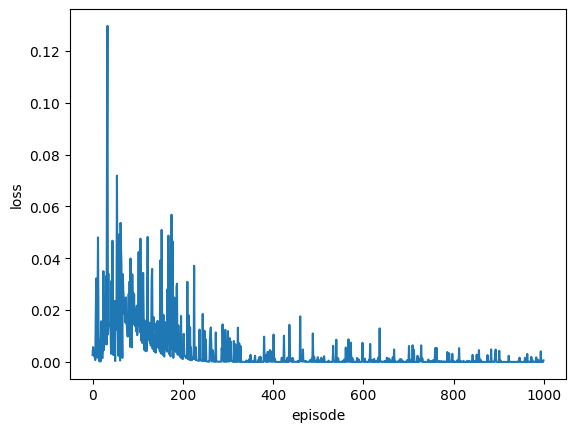

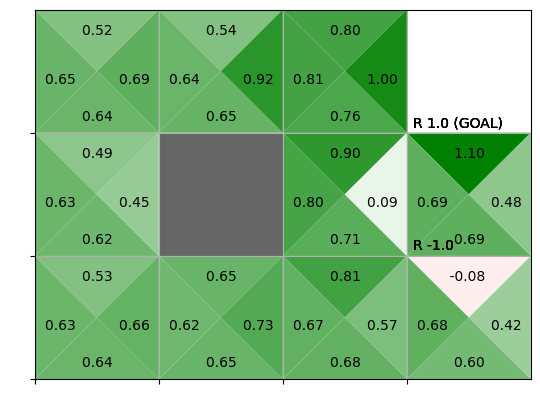

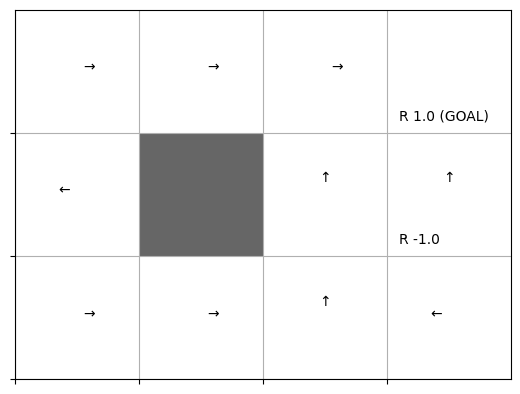

In [ ]:
# Double DQN

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ------------------------------
# 1. 前処理とネットワークの定義 (変更なし)
# ------------------------------
def one_hot(state):
    HEIGHT, WIDTH = 3, 4
    vec = np.zeros(HEIGHT * WIDTH, dtype=np.float32)
    y, x = state
    idx = WIDTH * y + x
    vec[idx] = 1.0
    return torch.tensor(vec[np.newaxis, :], dtype=torch.float32)

class QNet(nn.Module):
    def __init__(self, hidden_size=100, action_size=4):
        super().__init__()
        self.l1 = nn.Linear(12, hidden_size)
        self.l2 = nn.Linear(hidden_size, action_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.l2(x)
        return x

# --------------------------------------
# 2. エージェントの定義 (Double DQNに対応)
# --------------------------------------
class DoubleQLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.lr = 0.01
        self.epsilon = 0.1
        self.action_size = 4

        # [追加] Q-networkを2つ用意する (メインとターゲット)
        self.qnet = QNet()
        self.target_qnet = QNet()

        # [追加] 最初はターゲットとメインの重みを同じにしておく
        self.sync_qnet()

        self.optimizer = optim.SGD(self.qnet.parameters(), lr=self.lr)
        self.loss_fn = nn.MSELoss()

    # [追加] ターゲットネットワークをメインネットワークと同期する関数
    def sync_qnet(self):
        self.target_qnet.load_state_dict(self.qnet.state_dict())

    def get_action(self, state_vec):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_size)
        else:
            with torch.no_grad():
                qs = self.qnet(state_vec) # 行動選択はメインネットワークを使う
                return int(torch.argmax(qs))

    def update(self, state, action, reward, next_state, done):
        qs = self.qnet(state)
        q = qs[0, action]

        with torch.no_grad():
            if done:
                next_q = torch.tensor([0.0])
            else:
                # ----------------------------------------------------
                # [変更] ここが Double DQN の核心部分です
                # 1. 【メイン】ネットワークで次の状態における最適な「行動」を選ぶ
                next_action = torch.argmax(self.qnet(next_state))
                # 2. 【ターゲット】ネットワークで、その選んだ行動の「Q値」を算出する
                next_q = self.target_qnet(next_state)[0, next_action].unsqueeze(0)
                # ----------------------------------------------------

        target = self.gamma * next_q + reward
        loss = self.loss_fn(q.unsqueeze(0), target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

# ------------------------------
# 3. メインループと可視化
# ------------------------------
# env = GridWorld()  # 環境の初期化（元のコードと同様の前提）
agent = DoubleQLearningAgent()

episodes = 1000
# [追加] 何エピソードごとにターゲットネットワークを更新するか
sync_interval = 20

loss_history = []

for episode in range(episodes):
    state = env.reset()
    state = one_hot(state)
    total_loss, cnt = 0, 0
    done = False

    while not done:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)
        next_state = one_hot(next_state)

        loss = agent.update(state, action, reward, next_state, done)
        total_loss += loss
        cnt += 1
        state = next_state

    # [追加] 一定エピソードごとにターゲットネットワークをメインと同期させる
    if episode % sync_interval == 0:
        agent.sync_qnet()

    average_loss = total_loss / cnt
    loss_history.append(average_loss)

# グラフ描画と可視化は元のコードと同じ
plt.xlabel('episode')
plt.ylabel('loss')
plt.plot(range(len(loss_history)), loss_history)
plt.show()

Q = {}
for state in env.states():
    for action in env.action_space:
        q = agent.qnet(one_hot(state))[:, action]
        Q[state, action] = float(q.data)
env.render_q(Q)

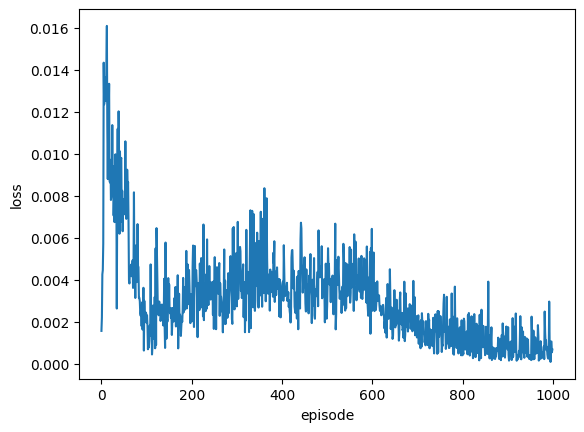

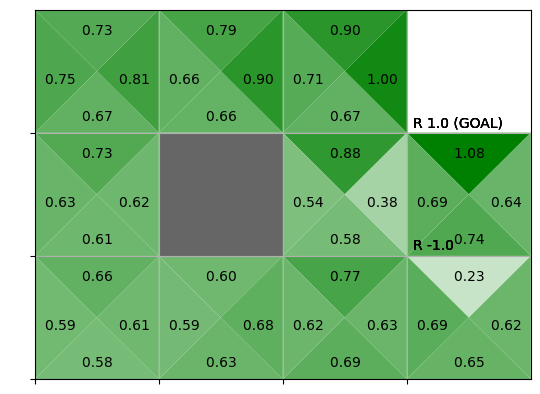

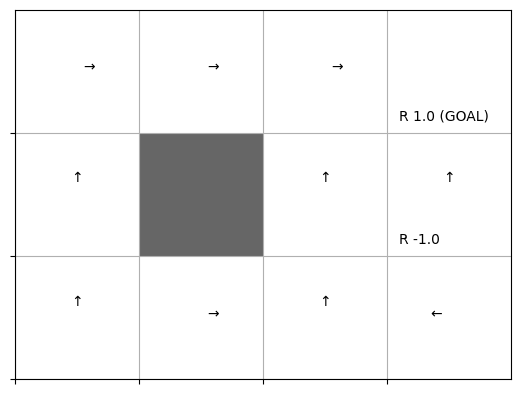

In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random
from collections import deque # [追加] メモリ（キュー）を使うためのライブラリ

# ------------------------------
# 1. 前処理とネットワークの定義 (変更なし)
# ------------------------------
def one_hot(state):
    HEIGHT, WIDTH = 3, 4
    vec = np.zeros(HEIGHT * WIDTH, dtype=np.float32)
    y, x = state
    idx = WIDTH * y + x
    vec[idx] = 1.0
    return torch.tensor(vec[np.newaxis, :], dtype=torch.float32)

class QNet(nn.Module):
    def __init__(self, hidden_size=100, action_size=4):
        super().__init__()
        self.l1 = nn.Linear(12, hidden_size)
        self.l2 = nn.Linear(hidden_size, action_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.l2(x)
        return x

# ------------------------------
# [追加] 2. 経験再生用のバッファ（メモリ）クラス
# ------------------------------

class ReplayBuffer:
    def __init__(self, buffer_size, batch_size):
        # dequeは指定サイズを超えると古いものから自動で押し出されるリストです
        self.buffer = deque(maxlen=buffer_size)
        self.batch_size = batch_size

    def add(self, state, action, reward, next_state, done):
        # 経験をタプルとしてメモリに追加
        self.buffer.append((state, action, reward, next_state, done))

    def __len__(self):
        return len(self.buffer)

    def get_batch(self):
        # メモリからバッチサイズ分だけランダムにサンプリング（抽出）
        data = random.sample(self.buffer, self.batch_size)
        
        # PyTorchで計算しやすいように、取り出したデータをテンソルにまとめる
        # stateは (1, 12) の形状なので、catで縦に積んで (batch_size, 12) にする
        state = torch.cat([x[0] for x in data])
        action = torch.tensor([x[1] for x in data], dtype=torch.int64)
        reward = torch.tensor([x[2] for x in data], dtype=torch.float32)
        next_state = torch.cat([x[3] for x in data])
        done = torch.tensor([x[4] for x in data], dtype=torch.int32) # doneは0か1
        
        return state, action, reward, next_state, done

# ------------------------------
# 3. エージェントの定義
# ------------------------------
class DDQN_Replay_Agent:
    def __init__(self):
        self.gamma = 0.9
        self.lr = 0.01
        self.epsilon = 0.1
        self.action_size = 4

        # [追加] メモリの設定
        self.batch_size = 32
        self.memory = ReplayBuffer(buffer_size=10000, batch_size=self.batch_size)

        self.qnet = QNet()
        self.target_qnet = QNet()
        self.sync_qnet()

        self.optimizer = optim.SGD(self.qnet.parameters(), lr=self.lr)
        self.loss_fn = nn.MSELoss()

    def sync_qnet(self):
        self.target_qnet.load_state_dict(self.qnet.state_dict())

    def get_action(self, state_vec):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_size)
        else:
            with torch.no_grad():
                qs = self.qnet(state_vec)
                return int(torch.argmax(qs))

    # [変更] updateメソッドは引数を取らず、メモリからデータを引いて学習する
    def update(self):
        # メモリにバッチサイズ分のデータが溜まるまでは学習しない
        if len(self.memory) < self.batch_size:
            return 0.0

        # メモリからランダムにバッチを取り出す
        state, action, reward, next_state, done = self.memory.get_batch()

        # 1. 現在の状態のQ値を計算 (バッチ処理)
        qs = self.qnet(state)
        # 実際に選んだ行動のQ値だけを抽出 (PyTorchの高度なインデックス指定)
        q = qs[torch.arange(self.batch_size), action]

        # 2. 次の状態のターゲットQ値を計算 (Double DQN & バッチ処理)
        with torch.no_grad():
            # メインが行動を選ぶ
            next_actions = torch.argmax(self.qnet(next_state), dim=1)
            # ターゲットが価値を評価する
            next_qs = self.target_qnet(next_state)
            next_q = next_qs[torch.arange(self.batch_size), next_actions]
            
            # done=1 (終了状態) の場合、未来の報酬はないので0にする
            next_q = next_q * (1 - done)

        target = reward + self.gamma * next_q

        # 損失関数の計算とパラメータ更新
        loss = self.loss_fn(q, target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

# ------------------------------
# 4. メインループと可視化
# ------------------------------
# env = GridWorld() 
agent = DDQN_Replay_Agent()

episodes = 1000
sync_interval = 20 
loss_history = []

for episode in range(episodes):
    state = env.reset()
    state = one_hot(state)
    total_loss, cnt = 0, 0
    done = False

    while not done:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)
        next_state = one_hot(next_state)

        # [変更] すぐにupdateせず、まずはメモリに経験を保存する！
        agent.memory.add(state, action, reward, next_state, done)
        
        # [変更] メモリ内のデータを使って学習する
        loss = agent.update()
        
        total_loss += loss
        cnt += 1
        state = next_state

    if episode % sync_interval == 0:
        agent.sync_qnet()

    # updateを行わなかった序盤は loss=0 なので記録の取り扱いに少し注意
    if cnt > 0:
        average_loss = total_loss / cnt
        loss_history.append(average_loss)

# --- 以下、グラフ描画と可視化は元のコードと同じ ---
plt.xlabel('episode')
plt.ylabel('loss')
plt.plot(range(len(loss_history)), loss_history)
plt.show()

Q = {}
for state in env.states():
    for action in env.action_space:
        q = agent.qnet(one_hot(state))[:, action]
        Q[state, action] = float(q.data)
env.render_q(Q)

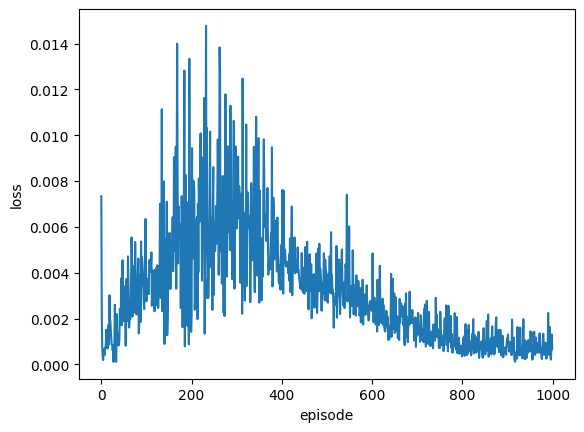

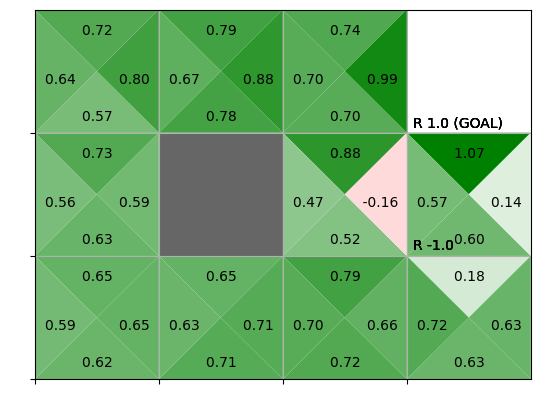

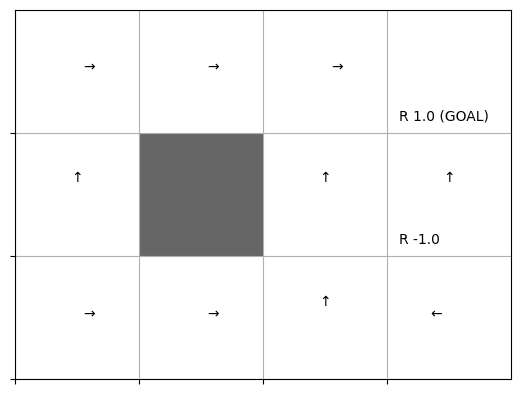

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random
from collections import deque # [追加] メモリ（キュー）を使うためのライブラリ

# ------------------------------
# 1. 前処理とネットワークの定義 (変更なし)
# ------------------------------
def one_hot(state):
    HEIGHT, WIDTH = 3, 4
    vec = np.zeros(HEIGHT * WIDTH, dtype=np.float32)
    y, x = state
    idx = WIDTH * y + x
    vec[idx] = 1.0
    return torch.tensor(vec[np.newaxis, :], dtype=torch.float32)

class DuelingQNet(nn.Module):
    def __init__(self, hidden_size=100, action_size=4):
        super().__init__()

        # 1. 共通の特徴抽出層（ここは今までと同じ）
        self.fc = nn.Linear(12, hidden_size)
        self.relu = nn.ReLU()

        # 2. 【変更】Value Stream: 状態の価値 V(s) を計算する層（出力は1次元）
        self.value_stream = nn.Linear(hidden_size, 1)

        # 3. 【変更】Advantage Stream: 各行動の相対的な価値 A(s,a) を計算する層（出力は4次元）
        self.advantage_stream = nn.Linear(hidden_size, action_size)

    def forward(self, x):
        # 共通層で特徴を抽出
        x = self.relu(self.fc(x))

        # それぞれのストリームに分岐させて計算
        v = self.value_stream(x)      # shape: (batch_size, 1)
        a = self.advantage_stream(x)  # shape: (batch_size, action_size)

        # 4. 【重要】Dueling DQNの結合式
        # a.mean(dim=1, keepdim=True) で、各状態における行動のAdvantageの平均を計算して引く
        q = v + (a - a.mean(dim=1, keepdim=True))

        return q

# ------------------------------
# [追加] 2. 経験再生用のバッファ（メモリ）クラス
# ------------------------------

class ReplayBuffer:
    def __init__(self, buffer_size, batch_size):
        # dequeは指定サイズを超えると古いものから自動で押し出されるリストです
        self.buffer = deque(maxlen=buffer_size)
        self.batch_size = batch_size

    def add(self, state, action, reward, next_state, done):
        # 経験をタプルとしてメモリに追加
        self.buffer.append((state, action, reward, next_state, done))

    def __len__(self):
        return len(self.buffer)

    def get_batch(self):
        # メモリからバッチサイズ分だけランダムにサンプリング（抽出）
        data = random.sample(self.buffer, self.batch_size)
        
        # PyTorchで計算しやすいように、取り出したデータをテンソルにまとめる
        # stateは (1, 12) の形状なので、catで縦に積んで (batch_size, 12) にする
        state = torch.cat([x[0] for x in data])
        action = torch.tensor([x[1] for x in data], dtype=torch.int64)
        reward = torch.tensor([x[2] for x in data], dtype=torch.float32)
        next_state = torch.cat([x[3] for x in data])
        done = torch.tensor([x[4] for x in data], dtype=torch.int32) # doneは0か1
        
        return state, action, reward, next_state, done

# ------------------------------
# 3. エージェントの定義
# ------------------------------
class DDQN_Replay_Agent:
    def __init__(self):
        self.gamma = 0.9
        self.lr = 0.01
        self.epsilon = 0.1
        self.action_size = 4

        # [追加] メモリの設定
        self.batch_size = 32
        self.memory = ReplayBuffer(buffer_size=10000, batch_size=self.batch_size)

        self.qnet = QNet()
        self.target_qnet = QNet()
        self.sync_qnet()

        self.optimizer = optim.SGD(self.qnet.parameters(), lr=self.lr)
        self.loss_fn = nn.MSELoss()

    def sync_qnet(self):
        self.target_qnet.load_state_dict(self.qnet.state_dict())

    def get_action(self, state_vec):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_size)
        else:
            with torch.no_grad():
                qs = self.qnet(state_vec)
                return int(torch.argmax(qs))

    # [変更] updateメソッドは引数を取らず、メモリからデータを引いて学習する
    def update(self):
        # メモリにバッチサイズ分のデータが溜まるまでは学習しない
        if len(self.memory) < self.batch_size:
            return 0.0

        # メモリからランダムにバッチを取り出す
        state, action, reward, next_state, done = self.memory.get_batch()

        # 1. 現在の状態のQ値を計算 (バッチ処理)
        qs = self.qnet(state)
        # 実際に選んだ行動のQ値だけを抽出 (PyTorchの高度なインデックス指定)
        q = qs[torch.arange(self.batch_size), action]

        # 2. 次の状態のターゲットQ値を計算 (Double DQN & バッチ処理)
        with torch.no_grad():
            # メインが行動を選ぶ
            next_actions = torch.argmax(self.qnet(next_state), dim=1)
            # ターゲットが価値を評価する
            next_qs = self.target_qnet(next_state)
            next_q = next_qs[torch.arange(self.batch_size), next_actions]
            
            # done=1 (終了状態) の場合、未来の報酬はないので0にする
            next_q = next_q * (1 - done)

        target = reward + self.gamma * next_q

        # 損失関数の計算とパラメータ更新
        loss = self.loss_fn(q, target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

# ------------------------------
# 4. メインループと可視化
# ------------------------------
# env = GridWorld() 
agent = DDQN_Replay_Agent()

episodes = 1000
sync_interval = 20 
loss_history = []

for episode in range(episodes):
    state = env.reset()
    state = one_hot(state)
    total_loss, cnt = 0, 0
    done = False

    while not done:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)
        next_state = one_hot(next_state)

        # [変更] すぐにupdateせず、まずはメモリに経験を保存する！
        agent.memory.add(state, action, reward, next_state, done)

        # [変更] メモリ内のデータを使って学習する
        loss = agent.update()

        total_loss += loss
        cnt += 1
        state = next_state

    if episode % sync_interval == 0:
        agent.sync_qnet()

    # updateを行わなかった序盤は loss=0 なので記録の取り扱いに少し注意
    if cnt > 0:
        average_loss = total_loss / cnt
        loss_history.append(average_loss)

# --- 以下、グラフ描画と可視化は元のコードと同じ ---
plt.xlabel('episode')
plt.ylabel('loss')
plt.plot(range(len(loss_history)), loss_history)
plt.show()

Q = {}
for state in env.states():
    for action in env.action_space:
        q = agent.qnet(one_hot(state))[:, action]
        Q[state, action] = float(q.data)
env.render_q(Q)